In [95]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [96]:
from dotenv import load_dotenv
load_dotenv()

True

Graph 1
==========

In [97]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

state = State(messages=[HumanMessage("Can You tell me about blackhole ?")])

state['messages'][0].pretty_print()

================================ Human Message =================================

Can You tell me about blackhole ?


Define Nodes

In [105]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

#response = chat.invoke(state['messages'])

#response.pretty_print()

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [106]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

Define The Graph

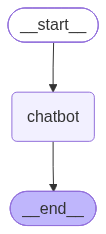

In [107]:
graph = StateGraph(State)


graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)


graph_complied = graph.compile()
graph_complied


In [108]:
#isinstance(graph_complied, Runnable), isinstance(graph, Runnable)

Test the Graph

In [109]:
graph_complied.invoke(state)


--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Understand User Query**: The user asks "Can You tell me about blackhole ?" - a straightforward request for information about black holes.

2.  **Identify Key Topics to Cover**:
   - Definition/What is a black hole?
   - How are they formed?
   - Key features/structure (event horizon, singularity, accretion disk, etc.)
   - Types of black holes (stellar, supermassive, intermediate, primordial)
   - How we detect/observe them
   - Interesting facts/phenomena (time dilation, spaghettification, Hawking radiation)
   - Current research/open questions
   - Keep it accessible but scientifically accurate

3.  **Structure the Response**:
   - Introduction/Definition
   - Formation
   - Structure/Key Features
   - Types
   - Detection/Observation
   - Fascinating Phenomena
   - Current Research & Mysteries
   - Conclusion
   - Keep it con

{'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Query**: The user asks "Can You tell me about blackhole ?" - a straightforward request for information about black holes.\n\n2.  **Identify Key Topics to Cover**:\n   - Definition/What is a black hole?\n   - How are they formed?\n   - Key features/structure (event horizon, singularity, accretion disk, etc.)\n   - Types of black holes (stellar, supermassive, intermediate, primordial)\n   - How we detect/observe them\n   - Interesting facts/phenomena (time dilation, spaghettification, Hawking radiation)\n   - Current research/open questions\n   - Keep it accessible but scientifically accurate\n\n3.  **Structure the Response**:\n   - Introduction/Definition\n   - Formation\n   - Structure/Key Features\n   - Types\n   - Detection/Observation\n   - Fascinating Phenomena\n   - Current Research & Mysteries\n   - Conclusion\n   - Keep it concise, well-organized, and engaging.\n\n4.  **Draft - Secti

Graph 2
====================

In [ ]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [ ]:
def ask(state:State)-> State:
    print("\n--------------> Entering Ask Question:")
    print("What is the Question?")
    return State(messages = [HumanMessage(input())])

ask(State(messages=[]))


--------------> Entering Ask Question:
What is the Question?


{'messages': [HumanMessage(content='who are you?', additional_kwargs={}, response_metadata={})]}

In [ ]:
chat = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

In [ ]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [ ]:
def ask_another(state:State)-> State:
    print("\n--------------> Entering ask another:")
    print("You want to ask another Question (Yes/No)")
    return State(messages = [HumanMessage(input())])

ask_another(State(messages=[]))


--------------> Entering ask another:
You want to ask another Question (Yes/No)


{'messages': [HumanMessage(content='Yes', additional_kwargs={}, response_metadata={})]}

In [ ]:
def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][0].content == "yes":
        return "ask"
    else:
        return "__end__"

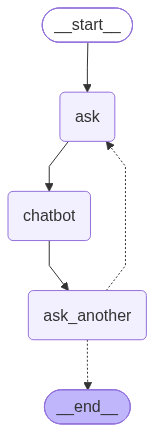

In [ ]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)

graph_complied = graph.compile()

graph_complied

In [ ]:
graph_complied.invoke(State(messages=[]))


--------------> Entering Ask Question:
What is the Question?

--------------> Entering Chatbot:


c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': '**ML** stands for **Machine Learning**. \n\nIt is a branch of **Artificial Intelligence (AI)** that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention.\n\nInstead of writing code with explicit rules for every scenario, you feed a machine learning algorithm a massive amount of data, and the computer "learns" the rules on its own.\n\n---\n\n### How Traditional Programming vs. Machine Learning Works\n\n* **Traditional Programming:**  \n  `Data` + `Rules` ➔ **Answers**  \n  *(A human writes the instructions telling the computer exactly what to do.)*\n\n* **Machine Learning:**  \n  `Data` + `Answers` ➔ **Rules**  \n  *(The computer analyzes the data and answers to figure out the underlying pattern/rules on its own.)*\n\n---\n\n### A Simple Analogy\nImagine teaching a child to recognize a dog:\n* *

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': '**Artificial Intelligence (AI)** refers to computer systems or machines designed to mimic human intelligence to perform tasks, solve problems, and learn from experience. \n\nInstead of just following rigid, pre-programmed rules, AI systems analyze massive amounts of data, recognize patterns, and make decisions or predictions based on that information.\n\nHere is a breakdown of how it works, its types, and how it is used today:\n\n---\n\n### 1. How Does AI Work?\nAt its core, modern AI relies on three main elements:\n* **Data:** AI needs information (text, images, numbers, audio) to learn from.\n* **Algorithms:** These are mathematical formulas and sets of rules that tell the AI how to process data.\n* **Machine Learning (ML):** A subfield of AI where computers automatically learn and improve from experience without being explicitly programmed for every scenario. *(Example: Showi

{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

Graph 3
=========

In [ ]:
my_list = add_messages([HumanMessage("Hii! I am ANIK."),
                                     AIMessage("Hey, Anik. How Can I Help You?")],
                                     [HumanMessage("Please Summarise recent news")])

my_list

[HumanMessage(content='Hii! I am ANIK.', additional_kwargs={}, response_metadata={}, id='776b54d7-016b-401e-b273-6e29bca99fd3'),
 AIMessage(content='Hey, Anik. How Can I Help You?', additional_kwargs={}, response_metadata={}, id='5fdcd059-7464-4ac9-845e-4ce2b61d8645', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please Summarise recent news', additional_kwargs={}, response_metadata={}, id='fd5fac55-bb11-4e53-91fc-286d3da9e142')]

In [ ]:
class State(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]

#add_message is a reducer function that defines how to combine the current state with the new incomming data in a structured way 

In [ ]:
def ask(state=State)-> State:
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [ ]:
chat = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

In [ ]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [ ]:
def ask_another(state=State)->State:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return state(messages=[AIMessage(question), HumanMessage(input())])


#define routing function

def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][0].content == "yes":
        return "ask"
    else:
        return "__end__"

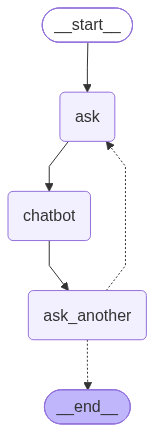

In [ ]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)

graph_complied = graph.compile()

graph_complied

In [ ]:
graph_complied.invoke(State(messages=[]))


-------> Entering the ask state
What is your Question ?

--------------> Entering Chatbot:


c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


ChatGoogleGenerativeAIError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 12.969519644s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT